# Assignment 3

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("../data/raw/carvana.csv")
df.head()

,Name,Year,Miles,Price
0,Chevrolet Trax,2018,41946,16990
1,GMC Terrain,2020,45328,23990
2,Jeep Wrangler,2012,81068,21590
3,Jeep Renegade,2019,35372,21590
4,BMW X,20173,68992,22990


In [22]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nSummary stats:")
print(df.describe())

Shape: (22000, 4)

Data types:
Name       str
Year     int64
Miles    int64
Price    int64
dtype: object

Missing values:
Name     0
Year     0
Miles    0
Price    0
dtype: int64

Summary stats:
               Year          Miles          Price
count  2.200000e+04   22000.000000   22000.000000
mean   1.946648e+05   54445.697318   20707.285136
std    1.630370e+06   25685.933926    6535.580304
min    2.009000e+03      53.000000   10990.000000
25%    2.014000e+03   35512.000000   16590.000000
50%    2.017000e+03   51890.000000   19590.000000
75%    2.020000e+03   73191.000000   22990.000000
max    2.022350e+07  120167.000000  102990.000000


In [23]:
# Any year outside a sane range (e.g. 1990-2026) is bad data -> mark as NaN
df.loc[(df["Year"] < 1990) | (df["Year"] > 2026), "Year"] = np.nan

print("Missing years after cleaning:", df["Year"].isnull().sum())
print("New Year range:")
print(df["Year"].describe())

Missing years after cleaning: 2851
New Year range:
count    19149.000000
mean      2016.166849
std          3.002296
min       2009.000000
25%       2014.000000
50%       2016.000000
75%       2019.000000
max       2023.000000
Name: Year, dtype: float64


In [24]:
df = df.dropna(subset=["Year"])
df["Year"] = df["Year"].astype(int)

print("Shape after dropping bad years:", df.shape)

Shape after dropping bad years: (19149, 4)


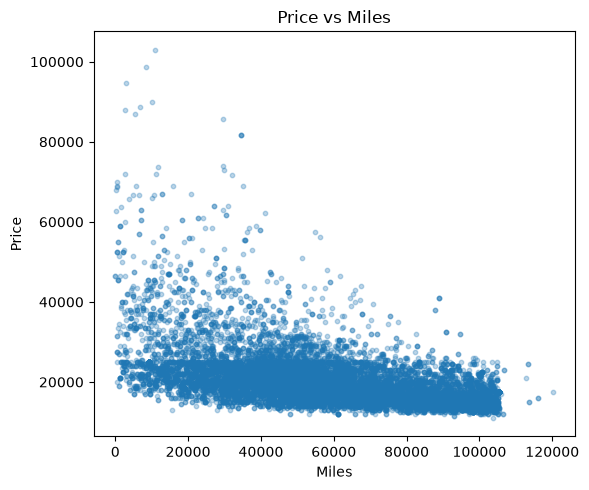

In [25]:
# Chart 1: Price vs Miles
plt.figure(figsize=(6, 5))
plt.scatter(df["Miles"], df["Price"], alpha=0.3, s=10)
plt.xlabel("Miles")
plt.ylabel("Price")
plt.title("Price vs Miles")
plt.tight_layout()
plt.savefig("../reports/a3_chart1.png", dpi=150)
plt.show()

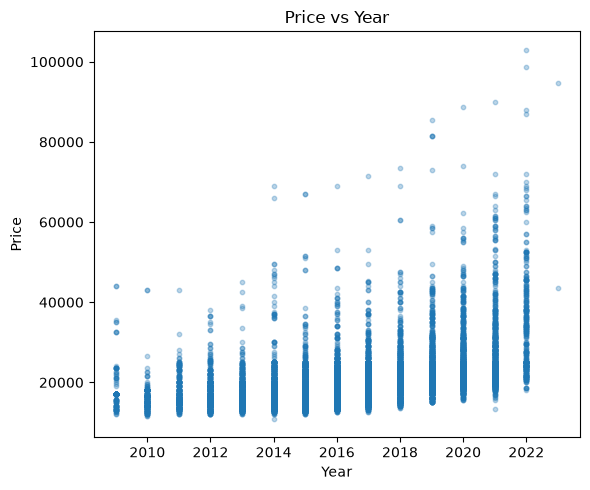

In [26]:
# Chart 2: Price vs Year
plt.figure(figsize=(6, 5))
plt.scatter(df["Year"], df["Price"], alpha=0.3, s=10)
plt.xlabel("Year")
plt.ylabel("Price")
plt.title("Price vs Year")
plt.tight_layout()
plt.savefig("../reports/a3_chart2.png", dpi=150)
plt.show()

# Linear Regression

In [27]:
# Features and target
X = df[["Year", "Miles"]]
y = df["Price"]

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# Predict on test set
lin_preds = lin_model.predict(X_test)

# Look at the coefficients (interpretable!)
print("Intercept (β0):", lin_model.intercept_)
print("Coefficient for Year:", lin_model.coef_[0])
print("Coefficient for Miles:", lin_model.coef_[1])

Intercept (β0): -1354268.7468746824
Coefficient for Year: 683.7379321931089
Coefficient for Miles: -0.07185014683158303


# Random Forest

In [28]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

print("Random Forest trained.")

Random Forest trained.


# Compare the two models

In [29]:
# Linear Regression metrics
lin_rmse = np.sqrt(mean_squared_error(y_test, lin_preds))
lin_r2 = r2_score(y_test, lin_preds)

# Random Forest metrics
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("=== Linear Regression ===")
print(f"RMSE: ${lin_rmse:,.2f}")
print(f"R²:   {lin_r2:.4f}")

print("\n=== Random Forest ===")
print(f"RMSE: ${rf_rmse:,.2f}")
print(f"R²:   {rf_r2:.4f}")

=== Linear Regression ===
RMSE: $5,330.28
R²:   0.3071

=== Random Forest ===
RMSE: $4,331.92
R²:   0.5423


## Conclusion

Random Forest outperformed Linear Regression on this dataset:
- RMSE: $4,331.92 (Random Forest) vs $5,330.28 (Linear Regression)
- R²: 0.5423 (Random Forest) vs 0.3071 (Linear Regression)

This makes sense because the relationship between Year, Miles, and Price
is not perfectly linear depreciation curves and market effects bend
in ways a straight line can't capture, while Random Forest's ensemble
of decision trees can model that non-linearity.

However, Linear Regression is still valuable for its interpretability:
we can directly see that each additional model year adds about $684
to price, and each mile driven subtracts about 7 cents. Random Forest
gives better accuracy but is a "black box" by comparison.

**Which would I trust more?** For raw predictive accuracy, Random Forest.
For explaining *why* a price is what it is to a non-technical stakeholder,
Linear Regression.